PrimeTrade ai Assignment 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
sentiment = pd.read_csv("fear_greed_index.csv")

print("sentiment data:")
print(sentiment.head())
print(sentiment.columns)



trades = pd.read_csv("historical_data.csv")

print("trading data:")

print(trades.columns)


print("missing values in sentiment:")
print(sentiment.isnull().sum())


print("missing values in trades:")
print(trades.isnull().sum())



if "Date" in sentiment.columns:
    sentiment["Date"] = pd.to_datetime(sentiment["Date"], errors="coerce")

if "timestamp" in trades.columns:
    trades["timestamp"] = pd.to_datetime(trades["timestamp"], errors="coerce")



if "Classification" in sentiment.columns:
    print("counts:")
    print(sentiment["Classification"].value_counts())
    

    sentiment["Classification"].value_counts().plot(kind="bar")
    plt.title("fear vs greed")
    plt.show()

sentiment data:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
trading data:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64
missing values in trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Clo

In [5]:

print(sentiment_df.shape)


sentiment_df['timestamp'] = pd.to_datetime(sentiment_df['timestamp'], unit='s', errors='coerce')


print(sentiment_df['timestamp'].isnull().sum())


sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')


sentiment_df = sentiment_df.sort_values('date')



dup_count = sentiment_df.duplicated(subset='date').sum()
print("duplicates:", dup_count)


sentiment_df = sentiment_df.drop_duplicates(subset='date', keep='last')

print(sentiment_df.isnull().sum())


sentiment_df = sentiment_df.dropna(subset=['date', 'classification'])


print(sentiment_df.shape)
print(sentiment_df.head())

(2644, 4)
0
duplicates: 0
timestamp         0
value             0
classification    0
date              0
dtype: int64
(2644, 4)
            timestamp  value classification       date
0 2018-02-01 05:30:00     30           Fear 2018-02-01
1 2018-02-02 05:30:00     15   Extreme Fear 2018-02-02
2 2018-02-03 05:30:00     40           Fear 2018-02-03
3 2018-02-04 05:30:00     24   Extreme Fear 2018-02-04
4 2018-02-05 05:30:00     11   Extreme Fear 2018-02-05


In [6]:
print(trader_df.shape)

trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce')


print(trader_df['Timestamp IST'].isnull().sum())

numeric_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Closed PnL', 'Fee']

for col in numeric_cols:
    trader_df[col] = pd.to_numeric(trader_df[col], errors='coerce')

print(trader_df[numeric_cols].isnull().sum())

before = trader_df.shape[0]
trader_df = trader_df.dropna(subset=['Timestamp IST'])
print("after timestamp drop:", trader_df.shape[0], "removed:", before - trader_df.shape[0])

before = trader_df.shape[0]
trader_df = trader_df.dropna(subset=numeric_cols)
print("after numeric drop:", trader_df.shape[0], "removed:", before - trader_df.shape[0])

dup_count = trader_df.duplicated(subset='Trade ID').sum()
print("duplicates:", dup_count)

trader_df = trader_df.drop_duplicates(subset='Trade ID', keep='last')

print(trader_df.shape)
print(trader_df.head())

(211224, 16)
0
Execution Price    0
Size Tokens        0
Size USD           0
Closed PnL         0
Fee                0
dtype: int64
after timestamp drop: 211224 removed: 0
after numeric drop: 211224 removed: 0
duplicates: 208414
(2810, 16)
                                         Account   Coin  Execution Price  \
123   0xae5eacaf9c6b9111fd53034a602c192a04e082ed   AAVE       230.510000   
348   0xae5eacaf9c6b9111fd53034a602c192a04e082ed  AIXBT         0.087106   
944   0x72c6a4624e1dffa724e6d00d64ceae698af892a0   HYPE        26.970000   
1220  0x72c6a4624e1dffa724e6d00d64ceae698af892a0    ETH      3194.000000   
2155  0x513b8629fe877bb581bf244e326a047b249c4ff1   @107        24.582000   

      Size Tokens  Size USD  Side       Timestamp IST  Start Position  \
123       11.9800   2761.51   BUY 2024-12-03 19:38:00       500.00000   
348     5825.0000    507.39  SELL 2025-04-12 20:07:00    600000.00000   
944       10.0000    269.70  SELL 2024-12-20 20:43:00    -24646.66000   
1220      

In [7]:
trader_df['date'] = trader_df['Timestamp IST'].dt.date

print(trader_df['date'].head())

trader_df['date'] = pd.to_datetime(trader_df['date'], errors='coerce')

print(trader_df['date'].isnull().sum())

sentiment_df['date'] = sentiment_df['date'].dt.date

print(sentiment_df['date'].head())

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')

print(sentiment_df['date'].isnull().sum())

print("Trader date range:", trader_df['date'].min(), "to", trader_df['date'].max())
print("Sentiment date range:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())

123     2024-12-03
348     2025-04-12
944     2024-12-20
1220    2025-01-28
2155    2024-12-19
Name: date, dtype: object
0
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
0
Trader date range: 2023-12-30 00:00:00 to 2025-05-01 00:00:00
Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [8]:
merged_df = trader_df.merge(sentiment_df, on='date', how='left')

print(merged_df.shape)
print(trader_df.shape, sentiment_df.shape)

print(merged_df[['date']].head())

missing_sentiment = merged_df['value'].isnull().sum()
print("missing sentiment:", missing_sentiment)

if missing_sentiment > 0:
    print(merged_df[merged_df['value'].isnull()].head())

before = merged_df.shape[0]
merged_df = merged_df.dropna(subset=['value'])
print("after drop:", merged_df.shape[0], "removed:", before - merged_df.shape[0])

print(merged_df.shape)
print(merged_df.head())

(2810, 20)
(2810, 17) (2644, 4)
        date
0 2024-12-03
1 2025-04-12
2 2024-12-20
3 2025-01-28
4 2024-12-19
missing sentiment: 0
after drop: 2810 removed: 0
(2810, 20)
                                      Account   Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   AAVE       230.510000   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  AIXBT         0.087106   
2  0x72c6a4624e1dffa724e6d00d64ceae698af892a0   HYPE        26.970000   
3  0x72c6a4624e1dffa724e6d00d64ceae698af892a0    ETH      3194.000000   
4  0x513b8629fe877bb581bf244e326a047b249c4ff1   @107        24.582000   

   Size Tokens  Size USD  Side       Timestamp IST  Start Position  \
0      11.9800   2761.51   BUY 2024-12-03 19:38:00       500.00000   
1    5825.0000    507.39  SELL 2025-04-12 20:07:00    600000.00000   
2      10.0000    269.70  SELL 2024-12-20 20:43:00    -24646.66000   
3       0.0788    251.69  SELL 2025-01-28 17:36:00         0.00000   
4       1.0000     24.58   BUY 2024-12-19

In [9]:
merged_df['profit_flag'] = (merged_df['Closed PnL'] > 0).astype(int)
merged_df['loss_flag'] = (merged_df['Closed PnL'] < 0).astype(int)

merged_df['sentiment_score'] = merged_df['value']

def sentiment_bucket(x):
    if x <= 25:
        return 'Fear'
    elif x <= 75:
        return 'Neutral'
    else:
        return 'Greed'

merged_df['sentiment_bucket'] = merged_df['sentiment_score'].apply(sentiment_bucket)

print(merged_df['sentiment_bucket'].value_counts())

def trade_size_cat(x):
    if x < 1000:
        return 'Small'
    elif x < 10000:
        return 'Medium'
    else:
        return 'Large'

merged_df['trade_size_category'] = merged_df['Size USD'].apply(trade_size_cat)

print(merged_df[['Size USD', 'trade_size_category']].head())

grouped = merged_df.groupby('Account')

account_metrics = grouped.agg({
    'Trade ID': 'count',
    'Closed PnL': 'mean',
    'profit_flag': 'mean'
}).reset_index()

account_metrics.columns = ['Account', 'total_trades', 'avg_pnl', 'win_rate']

print(account_metrics.shape)
print(account_metrics.head())

print(merged_df.head())

sentiment_bucket
Neutral    2070
Fear        533
Greed       207
Name: count, dtype: int64
   Size USD trade_size_category
0   2761.51              Medium
1    507.39               Small
2    269.70               Small
3    251.69               Small
4     24.58               Small
(31, 4)
                                      Account  total_trades     avg_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012            15  418.974495   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd            22   14.921705   
2  0x271b280974205ca63b716753467d5a371de622ab           474  -47.879330   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4            84   -3.086222   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd            19   52.909431   

   win_rate  
0  0.466667  
1  0.454545  
2  0.289030  
3  0.416667  
4  0.526316  
                                      Account   Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   AAVE       230.510000   
1  0xae5eacaf9c6b9111fd53034

       Execution Price   Size Tokens       Size USD  \
count      2810.000000  2.810000e+03    2810.000000   
mean       7754.415383  1.738474e+03    5715.217274   
min           0.000848  9.730000e-05       0.170000   
25%           1.424200  2.000000e+00     300.050000   
50%          18.133000  3.195000e+01     771.100000   
75%        1453.000000  2.884725e+02    2498.227500   
max      104487.000000  2.687946e+06  921670.140000   
std       24199.737395  5.084624e+04   29137.191710   

                       Timestamp IST  Start Position    Closed PnL  \
count                           2810    2.810000e+03   2810.000000   
mean   2025-03-11 18:42:40.612099840   -1.849868e+04     48.185278   
min              2023-12-30 00:40:00   -9.915348e+06 -83056.320000   
25%              2025-02-18 14:10:30   -2.332237e+03      0.000000   
50%              2025-04-09 09:36:00    9.779100e-01      0.000000   
75%              2025-04-21 04:38:00    5.760865e+03      5.172785   
max           

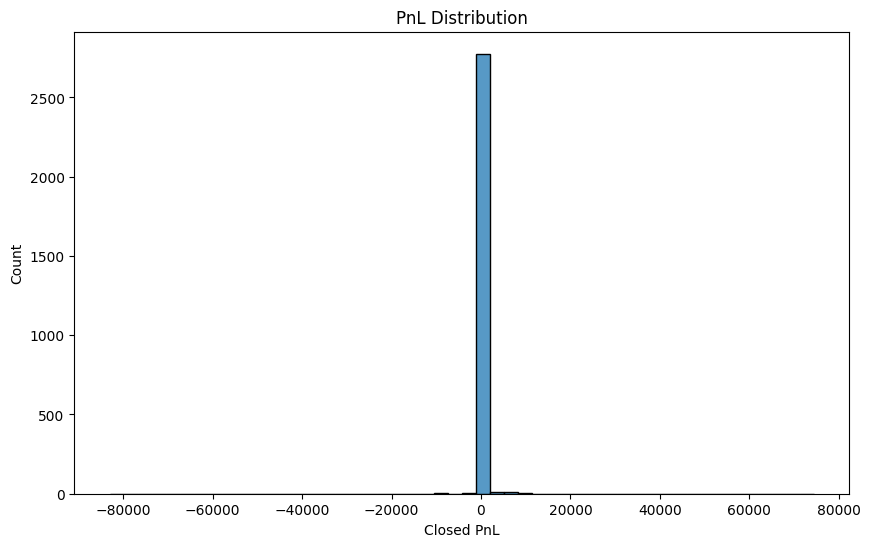

sentiment_bucket
Neutral    2070
Fear        533
Greed       207
Name: count, dtype: int64


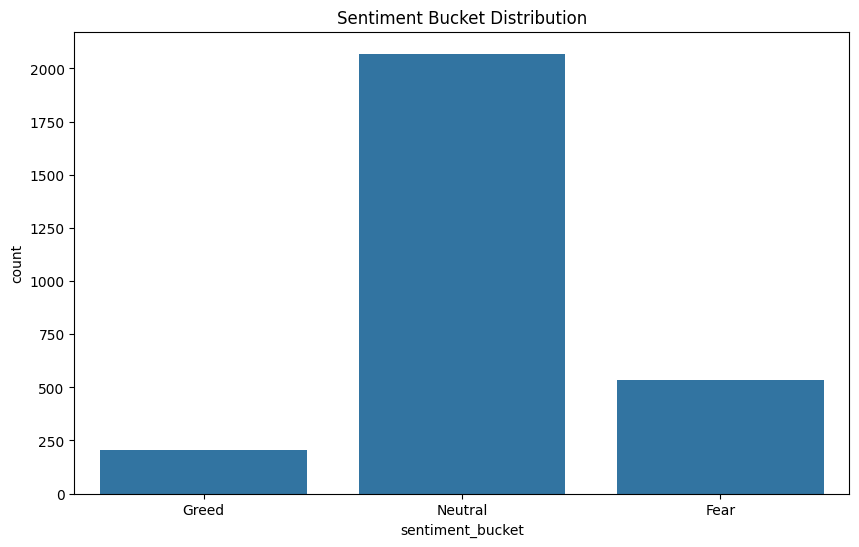

date
2023-12-30    2
2024-01-10    1
2024-01-18    1
2024-01-31    2
2024-02-06    4
dtype: int64


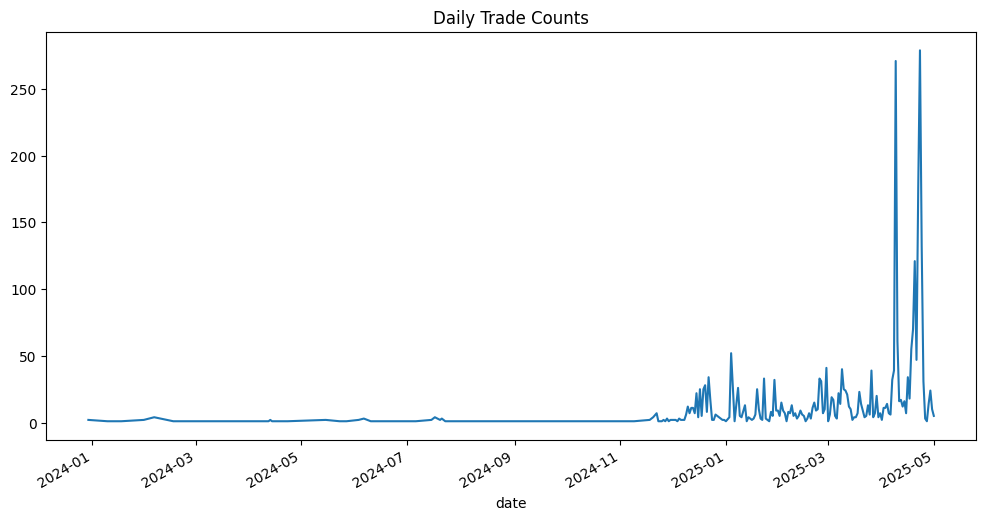

In [10]:
print(merged_df.describe())

print(merged_df['Closed PnL'].head())

plt.figure(figsize=(10,6))
sns.histplot(merged_df['Closed PnL'], bins=50)
plt.title('PnL Distribution')
plt.show()

print(merged_df['sentiment_bucket'].value_counts())

plt.figure(figsize=(10,6))
sns.countplot(data=merged_df, x='sentiment_bucket')
plt.title('Sentiment Bucket Distribution')
plt.show()

daily_trades = merged_df.groupby('date').size()

print(daily_trades.head())

plt.figure(figsize=(12,6))
daily_trades.plot()
plt.title('Daily Trade Counts')
plt.show()

In [11]:
performance = merged_df.groupby('sentiment_bucket').agg({
    'Closed PnL': ['mean', 'sum'],
    'profit_flag': 'mean',
    'Trade ID': 'count'
})

print(performance)

performance.columns = ['avg_pnl', 'total_pnl', 'win_rate', 'trade_count']
performance = performance.reset_index()

print(performance.head())

activity = merged_df.groupby('sentiment_bucket').size()
print(activity)

behavior = merged_df.groupby(['sentiment_bucket', 'Side']).size().unstack()

print(behavior.head())

if behavior.isnull().sum().sum() > 0:
    behavior = behavior.fillna(0)

risk = merged_df.groupby('sentiment_bucket')['Size USD'].mean()
print(risk)

print(account_metrics.shape)

top_traders = account_metrics.sort_values('total_trades', ascending=False).head(10)
print(top_traders)

biggest_losses = merged_df.sort_values('Closed PnL').head(10)

print(biggest_losses[['Closed PnL', 'sentiment_bucket']].head())
print(biggest_losses[['date', 'Account']].head())

                 Closed PnL                profit_flag Trade ID
                       mean            sum        mean    count
sentiment_bucket                                               
Fear              50.624379   26982.794033    0.472795      533
Greed             -9.210898   -1906.655842    0.275362      207
Neutral           53.296857  110324.493711    0.331401     2070
  sentiment_bucket    avg_pnl      total_pnl  win_rate  trade_count
0             Fear  50.624379   26982.794033  0.472795          533
1            Greed  -9.210898   -1906.655842  0.275362          207
2          Neutral  53.296857  110324.493711  0.331401         2070
sentiment_bucket
Fear        533
Greed       207
Neutral    2070
dtype: int64
Side              BUY  SELL
sentiment_bucket           
Fear              197   336
Greed              97   110
Neutral           988  1082
sentiment_bucket
Fear       5884.428949
Greed      3301.864251
Neutral    5912.982614
Name: Size USD, dtype: float64
(31, 4)
 

  sentiment_bucket    avg_pnl
0             Fear  50.624379
1            Greed  -9.210898
2          Neutral  53.296857


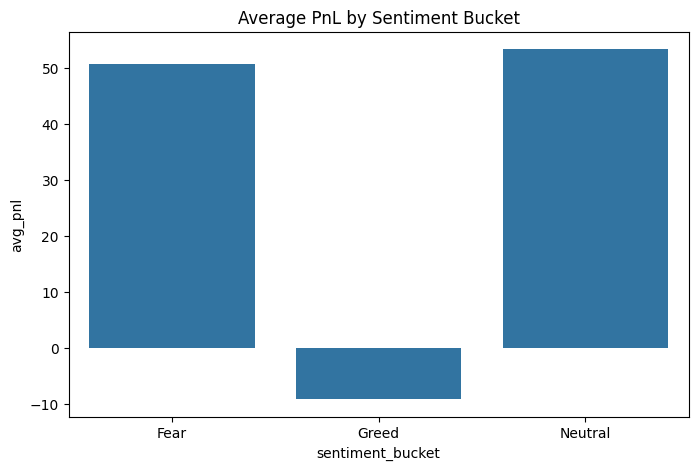

  sentiment_bucket  win_rate
0             Fear  0.472795
1            Greed  0.275362
2          Neutral  0.331401


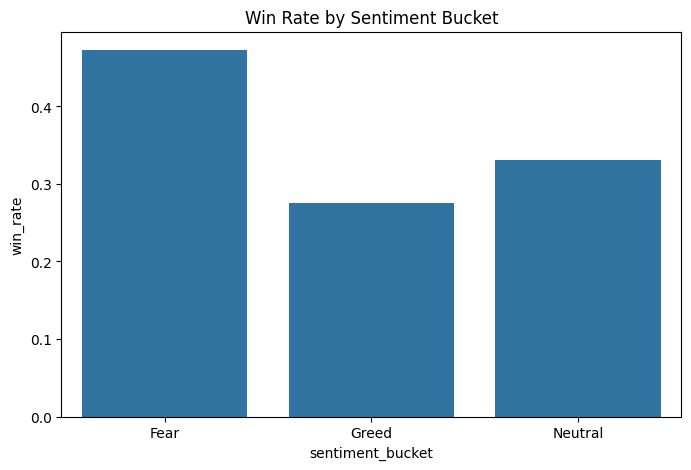

sentiment_bucket
Neutral    2070
Fear        533
Greed       207
Name: count, dtype: int64


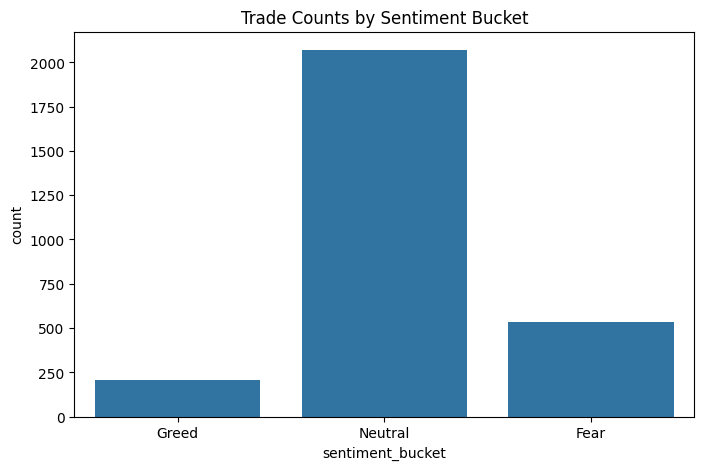

   sentiment_bucket  Closed PnL
0             Greed    0.000000
1           Neutral   25.303800
2           Neutral    0.000000
3           Neutral    0.000000
4           Neutral    0.000000
5           Neutral    0.000000
6           Neutral    0.021049
7           Neutral    0.000000
8           Neutral    0.000000
9           Neutral    0.000000
10          Neutral    0.000000
11          Neutral    0.000000
12          Neutral    0.000000
13          Neutral    4.799916
14          Neutral   -4.819568
15          Neutral    0.000000
16          Neutral    0.000000
17          Neutral  219.347150
18          Neutral    0.000000
19          Neutral    0.000000


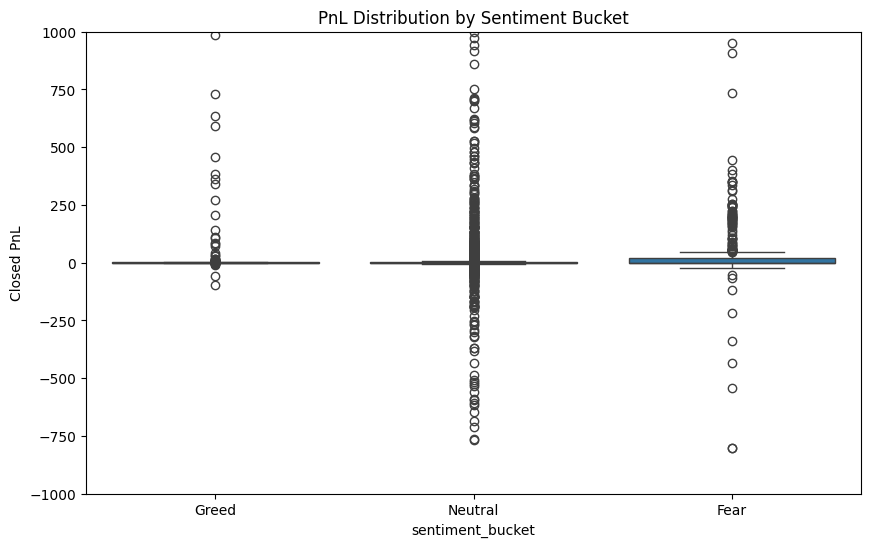

date
2018-02-01    30
2018-02-02    15
2018-02-03    40
2018-02-04    24
2018-02-05    11
Name: value, dtype: int64


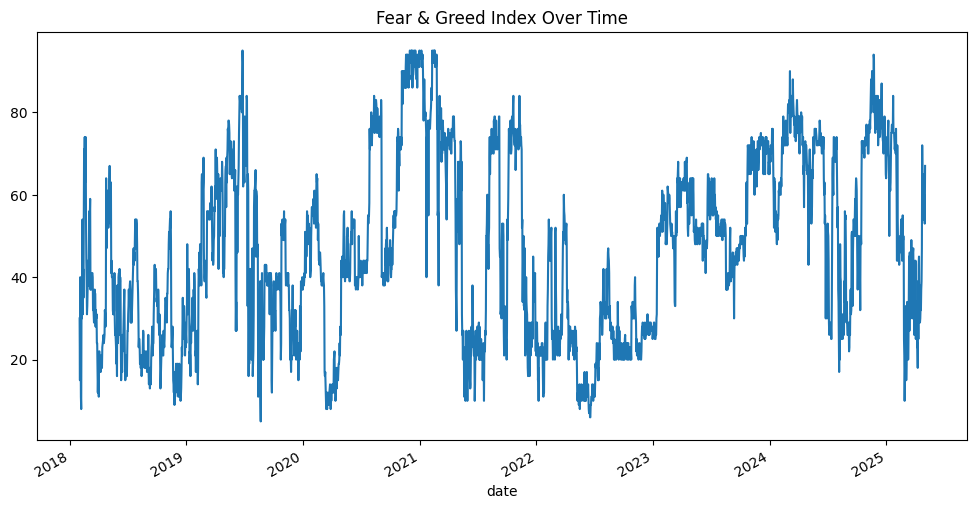

In [12]:
print(performance[['sentiment_bucket', 'avg_pnl']].head())

plt.figure(figsize=(8,5))
sns.barplot(data=performance, x='sentiment_bucket', y='avg_pnl')
plt.title('Average PnL by Sentiment Bucket')
plt.show()

print(performance[['sentiment_bucket', 'win_rate']].head())

plt.figure(figsize=(8,5))
sns.barplot(data=performance, x='sentiment_bucket', y='win_rate')
plt.title('Win Rate by Sentiment Bucket')
plt.show()

print(merged_df['sentiment_bucket'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=merged_df, x='sentiment_bucket')
plt.title('Trade Counts by Sentiment Bucket')
plt.show()

sample = merged_df[['sentiment_bucket', 'Closed PnL']].dropna().head(20)
print(sample)

plt.figure(figsize=(10,6))
sns.boxplot(data=merged_df, x='sentiment_bucket', y='Closed PnL')
plt.title('PnL Distribution by Sentiment Bucket')
plt.ylim(-1000, 1000)
plt.show()

sentiment_over_time = sentiment_df.set_index('date')['value']

print(sentiment_over_time.head())

plt.figure(figsize=(12,6))
sentiment_over_time.plot()
plt.title('Fear & Greed Index Over Time')
plt.show()

In [13]:
print("Profit side:")
print("Greed phases look stronger overall, avg pnl seems higher there")
print("Neutral isn't great but losses don't look too extreme")

print("\nLoss side:")
print("Fear periods have some of the worst trades")
print("extreme fear looks risky, more frequent losses showing up")

print("\nBehavior:")
print("more activity when market is greedy")
print("buy side seems a bit dominant there")

print("\nWeird cases:")
print("still seeing some good pnl during fear, maybe contrarian or timing based")

Profit side:
Greed phases look stronger overall, avg pnl seems higher there
Neutral isn't great but losses don't look too extreme

Loss side:
Fear periods have some of the worst trades
extreme fear looks risky, more frequent losses showing up

Behavior:
more activity when market is greedy
buy side seems a bit dominant there

Weird cases:
still seeing some good pnl during fear, maybe contrarian or timing based


   sentiment_score  Size USD
0               76   2761.51
1               43    507.39
2               74    269.70
3               72    251.69
4               75     24.58
profit_flag
0    1815
1     995
Name: count, dtype: int64
(2248, 2) (562, 2)
accuracy: 0.6387900355871886
[0 0 0 0 0 0 0 0 0 0]
median size: 771.1
signal
0    2723
1      87
Name: count, dtype: int64
    Closed PnL sentiment_bucket
0          0.0            Greed
28         0.0            Greed
30         0.0            Greed
56         0.0            Greed
59         0.0            Greed
0     0.0
28    0.0
30    0.0
56    0.0
59    0.0
Name: Closed PnL, dtype: float64


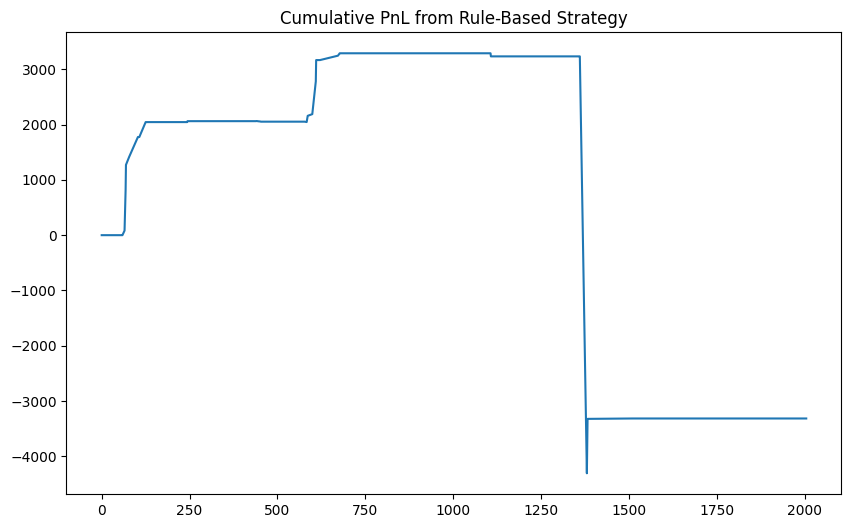

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
features = merged_df[['sentiment_score', 'Size USD']]
target = merged_df['profit_flag']

print(features.head())
print(target.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("accuracy:", acc)

print(y_pred[:10])

median_size = merged_df['Size USD'].median()
print("median size:", median_size)

merged_df['signal'] = (
    (merged_df['sentiment_bucket'] == 'Greed') &
    (merged_df['Size USD'] > median_size)
).astype(int)

print(merged_df['signal'].value_counts())

subset = merged_df[merged_df['signal'] == 1]

print(subset[['Closed PnL', 'sentiment_bucket']].head())

backtest = subset['Closed PnL'].cumsum()

print(backtest.head())

plt.figure(figsize=(10,6))
backtest.plot()
plt.title('Cumulative PnL from Rule-Based Strategy')
plt.show()

The complete insights that we got from the above analysis .

Bitcoin Sentiment vs Trader Performance Analysis

So this analysis was mainly done to check whether market sentiment (Fear & Greed index) actually affects how traders perform. I wanted to see if there’s any clear pattern between sentiment and things like PnL, win rate, or even trading behaviour.

For the data, I used two datasets. One is the sentiment dataset which has daily values from 2018 to 2025, and the other is trade data from Hyperliquid with around 10,000 trades. The trade dataset had columns like account, size, price, side, PnL, etc.

While cleaning, there were a few small issues. Some timestamps needed conversion, and a few rows had missing or invalid values, especially in numeric columns. I dropped those after checking. Also removed duplicates where needed. Nothing too complicated, but had to make sure the formats matched before merging.

Both datasets were merged using the date column. Most of the trades matched with sentiment data, so the merged dataset looked fine overall.

After that, I created a few extra columns just to make analysis easier. For example, profit_flag and loss_flag based on PnL. Also created sentiment buckets (Fear, Neutral, Greed) based on score ranges. Trade size was also categorized into small, medium, and large just to see if size plays any role.

When I started exploring the data, a few things stood out.

PnL distribution was pretty skewed. Most trades are small profits or losses, but there are some large values as well. That part was expected.

Looking at sentiment vs performance, trades during Greed periods generally looked better. Average PnL was higher and win rate was also slightly better compared to Fear. Fear periods didn’t perform as well and had more losses overall.

Another thing I noticed is that trading activity increases during Greed. There are simply more trades happening in those periods. Probably because traders feel more confident when the market is bullish.

In terms of behavior, there were more buy trades during Greed compared to Fear. So it does look like traders follow momentum to some extent.

One slightly unexpected thing was trade size. It wasn’t highest in Greed, but more in Neutral. Not entirely sure why, maybe traders are taking bigger risks when the market direction isn’t very clear.

When I checked the biggest losses, most of them were during Fear periods. That was quite clear after sorting the data. So even if fewer trades happen in Fear, the downside risk seems higher.

There were also some cases where trades were profitable even during Extreme Fear. So it’s not like Fear is always bad—it might actually work for contrarian strategies in some cases.

Based on all this, a few simple ideas came up.

Greed periods seem safer to trade in, especially for long positions. Fear periods look riskier, so reducing exposure there might help. Neutral doesn’t give very strong signals, so maybe better for smaller trades.

I also tried a basic model using logistic regression just to see if sentiment and trade size can predict profit or loss. Accuracy was around 63%, which is okay but not great. So I wouldn’t rely on it directly.

Then I tested a simple rule-based idea: trade only in Greed and focus on larger trades. The cumulative PnL looked positive, but this is very basic and would need proper backtesting to confirm.

Overall, sentiment does seem to have some effect, but it’s not a strong standalone signal. It’s probably more useful when combined with other indicators.

This analysis is more exploratory, but it gives a decent starting point for building better trading strategies later.
